# **Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Install/Upgrade Required Libraries**

In [2]:
%pip install -U transformers
%pip install -U accelerate
%pip install -U sentencepiece
%pip install -U pandas
%pip install -U scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 72.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.2
    Uninstalling transformers-4.53.2:
      Successfully uninstalled transformers-4.53.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

# Upgrade the 'datasets' Library

In [3]:
!pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.7.0
    Uninstalling fsspec-2025.7.0:
      Successfully uninstalled fsspec-2025.7.0
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.
gcsfs 2025.7.0 requires fsspec==2025.7.0, but you have fsspec 2025.3.0 which is incompatible.


# **Load, Preprocess, Split, and Encode Dataset**

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# Load the dataset (assuming it's in the same mounted Google Drive location)
try:
    df = pd.read_csv('/content/drive/MyDrive/ok/Bengali hate speech .csv')
    # Rename columns for consistency
    df.rename(columns={'sentence': 'Comment', 'hate': 'Label'}, inplace=True)
    # Convert numerical label (0/1) to 'normal'/'hate' strings for consistency with original script's logic if needed,
    # then map back to numerical for classification.
    # The original CSV has 0/1, so we'll map that directly
    df['Label'] = df['Label'].map({0: 'normal', 1: 'hate'})

except FileNotFoundError:
    print("Error: 'Bengali hate speech .csv' not found. Please ensure it's in your Google Drive and mounted.")
    # Fallback to local if running in Kaggle or specific environment
    # df = pd.read_csv('../input/your-dataset-name/Bengali hate speech .csv')

# Drop the 'category' column as it's not used for this classification task
df = df.drop(columns=['category'])

# Map 'Label' (hate/normal) to numerical IDs (0 and 1) for classification
# We'll use 0 for 'normal' and 1 for 'hate'
label_map = {'normal': 0, 'hate': 1}
df['label'] = df['Label'].map(label_map) # New column 'label' with numerical IDs

# Get the unique labels and their IDs for the model
id2label = {id: label for label, id in label_map.items()}
label2id = label_map

print(f"Original DataFrame shape: {df.shape}")
print(f"Label mapping: {label_map}")
print(f"id2label: {id2label}")

# Split the dataset into training, validation, and test sets
# Using 80% for training, 10% for validation, 10% for testing
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train DataFrame shape: {train_df.shape}")
print(f"Validation DataFrame shape: {val_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")

# Convert pandas DataFrames to Hugging Face Dataset objects
# For sequence classification, we typically use 'text' and 'label' columns
train_data = Dataset.from_pandas(train_df.rename(columns={'Comment': 'text'}))
eval_data = Dataset.from_pandas(val_df.rename(columns={'Comment': 'text'}))
test_data = Dataset.from_pandas(test_df.rename(columns={'Comment': 'text'})) # Prepare test_data as well

# Create a DatasetDict for easier management
raw_datasets = DatasetDict({
    "train": train_data,
    "validation": eval_data,
    "test": test_data
})

print("\nDataset split and labels encoded successfully.")
print(f"Sample from train_data (first 3):")
print(raw_datasets["train"][:3])

Original DataFrame shape: (30000, 3)
Label mapping: {'normal': 0, 'hate': 1}
id2label: {0: 'normal', 1: 'hate'}
Train DataFrame shape: (24000, 3)
Validation DataFrame shape: (3000, 3)
Test DataFrame shape: (3000, 3)

Dataset split and labels encoded successfully.
Sample from train_data (first 3):
{'text': ['ওপেনার বেসমেন্ট এ রখমি দরকার উরাদোরা মাইর।', 'স্যার আপনাকে উইকিপিডিয়ায় মৃত দেখাচ্ছে কেন??', 'ঐ কূত্তার বাচ্চা তুই মোহাম্মাদ নিয়ে গালি দিল ক\u200d্যান তুই বাংলাদেশ এ আসতোর ধোন কাইট্টা কুত্তা দিয়া খাওয়ামু'], 'Label': ['normal', 'normal', 'hate'], 'label': [0, 0, 1], '__index_level_0__': [12028, 26696, 9855]}


# **Visualize Dataset Class Distribution After Splitting**

Visualizing dataset class distribution after splitting...


/tmp/ipython-input-14-2733060939.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=plot_df_train, palette='viridis')
/tmp/ipython-input-14-2733060939.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=plot_df_val, palette='viridis')
/tmp/ipython-input-14-2733060939.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=plot_df_test, palette='viridis')


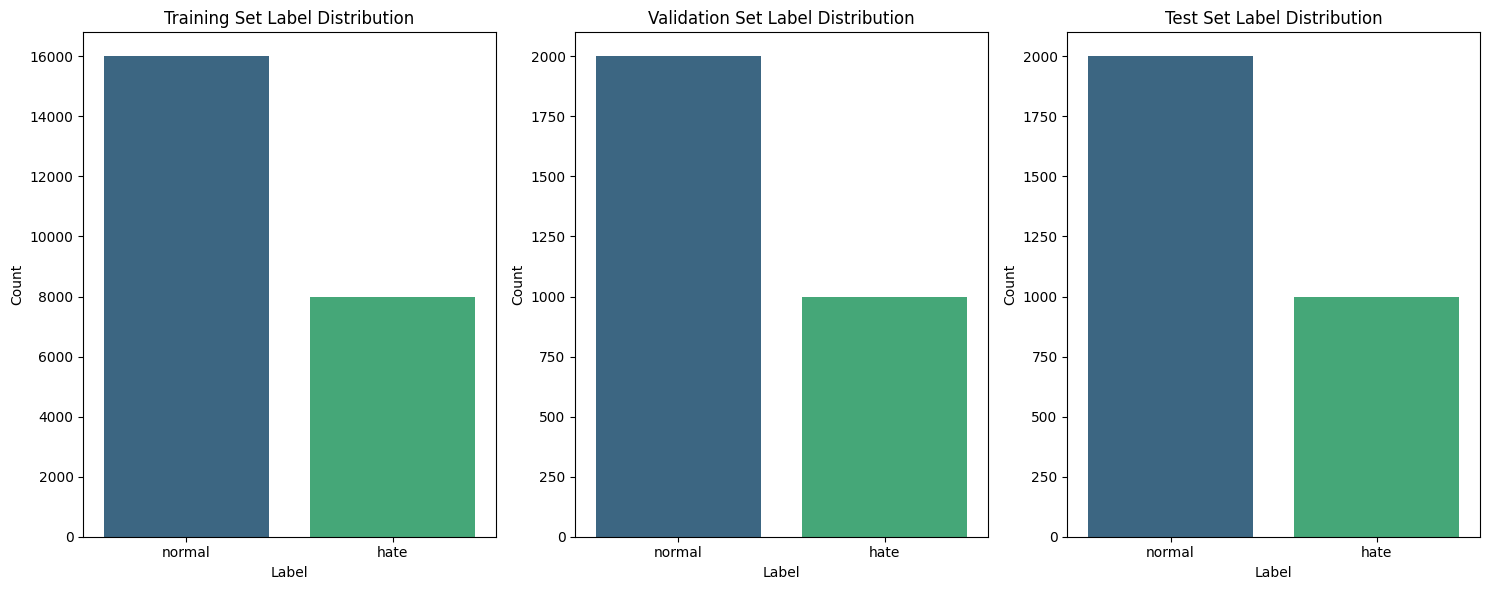


Dataset class distribution plots generated successfully.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming train_df, val_df, test_df are available from Step 4

print("Visualizing dataset class distribution after splitting...")

# Combine dataframes for easier plotting
# Ensure 'label' column is numerical (0/1) for direct use with value_counts
# Re-map numerical label to 'normal'/'hate' strings for plot readability
plot_df_train = train_df.copy()
plot_df_val = val_df.copy()
plot_df_test = test_df.copy()

plot_df_train['Label Type'] = 'Training Set'
plot_df_val['Label Type'] = 'Validation Set'
plot_df_test['Label Type'] = 'Test Set'

# Concatenate all dataframes
all_splits_df = pd.concat([plot_df_train, plot_df_val, plot_df_test])

# Create a figure with subplots for each split or a single combined plot
plt.figure(figsize=(15, 6))

# Plot for Training Set
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.countplot(x='Label', data=plot_df_train, palette='viridis')
plt.title('Training Set Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

# Plot for Validation Set
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.countplot(x='Label', data=plot_df_val, palette='viridis')
plt.title('Validation Set Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

# Plot for Test Set
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.countplot(x='Label', data=plot_df_test, palette='viridis')
plt.title('Test Set Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("\nDataset class distribution plots generated successfully.")

# **Load Tokenizer & Model with Class Weights**

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np # Import numpy for array manipulation if needed, but not strictly for this.

# Define the model name
model_name = "xlm-roberta-base"

# Load the tokenizer
print(f"Loading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("Tokenizer loaded successfully.")

# Calculate class weights based on the training data distribution
# Assuming 'raw_datasets' is available and correctly contains the 'train' split with 'label' column
# Get counts of each class from the training set
num_normal_train = raw_datasets["train"].filter(lambda x: x["label"] == 0).num_rows
num_hate_train = raw_datasets["train"].filter(lambda x: x["label"] == 1).num_rows
total_train_samples = num_normal_train + num_hate_train

# Calculate inverse class frequency weights
# weight for class c = total_samples / (num_classes * samples_in_class_c)
# This gives more weight to the minority class
weight_normal = total_train_samples / (2 * num_normal_train)
weight_hate = total_train_samples / (2 * num_hate_train)

# Convert to a PyTorch tensor, ensuring it's on the same device as the model and is float
# Order of weights corresponds to label IDs: [weight_for_label_0, weight_for_label_1]
class_weights_tensor = torch.tensor([weight_normal, weight_hate], dtype=torch.float)

print(f"Calculated Class Weights: Normal (ID 0): {weight_normal:.4f}, Hate (ID 1): {weight_hate:.4f}")


# Load the model for sequence classification
# We need to specify the number of labels and the mapping for them
print(f"Loading model for sequence classification for {model_name}...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_map), # Number of unique labels (2: hate, normal)
    id2label=id2label,
    label2id=label2id
)
print("Model loaded successfully.")

# Move model to GPU if available and then apply weights
if torch.cuda.is_available():
    model.to('cuda')
    class_weights_tensor = class_weights_tensor.to('cuda') # Move weights to GPU
    print("Model moved to GPU.")
else:
    print("CUDA not available. Model will run on CPU (will be slower).")

# Apply the class weights to the model's loss function
# AutoModelForSequenceClassification uses CrossEntropyLoss internally.
# We can modify it to use our calculated weights.
model.config.problem_type = "single_label_classification" # Ensure this is correctly set
model.loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

print("\nTokenizer and Model loaded, and Class Weights applied to loss function. Ready for tokenization.")

Loading tokenizer for xlm-roberta-base...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Filter:   0%|          | 0/24000 [00:00<?, ? examples/s]

Calculated Class Weights: Normal (ID 0): 0.7500, Hate (ID 1): 1.5000
Loading model for sequence classification for xlm-roberta-base...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully.
Model moved to GPU.

Tokenizer and Model loaded, and Class Weights applied to loss function. Ready for tokenization.


# **Tokenize and Format Datasets**

In [6]:
# Assuming 'tokenizer', 'raw_datasets' are available from previous steps

# Define the tokenization function
def tokenize_function(examples):
    # Ensure truncation and padding are handled.
    # XLM-R base's max sequence length is 512.
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=512, # XLM-RoBERTa base max sequence length
        padding="max_length" # Pad to max_length
    )

print("Tokenizing datasets...")
# Apply tokenization to the datasets
# We keep the 'label' column which contains the numerical IDs
tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "Label", "__index_level_0__"] # Remove original text and pandas index, keep 'label'
)

# Set the format for PyTorch
tokenized_datasets.set_format("torch")

print("Datasets tokenized successfully.")
print("\nSample of tokenized training data (input_ids):")
print(tokenized_datasets["train"][0]['input_ids'][:20]) # Print first 20 tokens
print("\nSample of tokenized training data (attention_mask):")
print(tokenized_datasets["train"][0]['attention_mask'][:20]) # Print first 20 tokens
print("\nSample of tokenized training data (label):")
print(tokenized_datasets["train"][0]['label']) # Print label

Tokenizing datasets...


Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Datasets tokenized successfully.

Sample of tokenized training data (input_ids):
tensor([     0,   2114,  59311,  50321,  37555,   3458, 105354,   4577,  25792,
         15314,  30550, 219840,  16447,   5534, 139983,   5534, 174885,    999,
           125,      2])

Sample of tokenized training data (attention_mask):
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Sample of tokenized training data (label):
tensor(0)


# **Define Training Arguments and Initialize Trainer**

In [7]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# Define compute_metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # For sequence classification, predictions are logits, so we take argmax
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted') # 'weighted' handles class imbalance
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')

    return {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# Define training arguments
training_args = TrainingArguments(
    output_dir="./xlm_roberta_hate_speech_results", # Directory for saving checkpoints
    num_train_epochs=5,                          # Start with 3 epochs for quicker training and good results
    per_device_train_batch_size=16,              # Batch size per GPU. Adjust based on VRAM.
    gradient_accumulation_steps=1,               # No accumulation needed with larger batch size
    per_device_eval_batch_size=16,               # Batch size for evaluation
    warmup_steps=500,                            # Number of warmup steps for learning rate scheduler
    weight_decay=0.01,                           # Strength of weight decay
    logging_dir="./xlm_roberta_logs",            # Directory for logs
    logging_steps=50,                            # Log metrics every 50 steps
    eval_strategy="epoch",                       # CORRECTED: Changed from 'evaluation_strategy' to 'eval_strategy'
    save_strategy="epoch",                       # Save checkpoint at the end of each epoch
    load_best_model_at_end=True,                 # Load the best model based on eval_loss at the end of training
    metric_for_best_model="f1",                  # Metric to monitor for best model saving
    report_to="none",                            # No reporting to WandB for now (can change to "wandb" if desired)
    fp16=True,                                   # Enable mixed precision training
)

# Initialize the Trainer
print("Initializing Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer, # Tokenizer is passed to Trainer for potential internal use
    compute_metrics=compute_metrics, # Pass the compute_metrics function
)
print("Trainer initialized successfully.")

Initializing Trainer...
Trainer initialized successfully.


/tmp/ipython-input-7-23843329.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


# **Start Model Fine-Tuning**

In [8]:
# Assuming 'trainer' object is initialized from the previous step

print("Starting fine-tuning...")
trainer.train()
print("Fine-tuning completed.")

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.360500,0.352447,0.879667,0.879279,0.879025,0.879667
2,0.319400,0.322322,0.874000,0.875794,0.881313,0.874000
3,0.318800,0.294322,0.896667,0.896919,0.897257,0.896667
4,0.241000,0.308263,0.890000,0.891392,0.895665,0.890000
5,0.275300,0.269019,0.903000,0.903155,0.903347,0.903000


Fine-tuning completed.


# **Evaluate Model on Test Set**

In [9]:
# Assuming 'trainer' object is available from the previous step
# And 'tokenized_datasets["test"]' is available from Step 4 (Revised)

print("Evaluating the model on the test set...")
test_results = trainer.evaluate(tokenized_datasets["test"])

print("\n--- Test Set Evaluation Results ---")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

print("\nEvaluation completed.")

Evaluating the model on the test set...



--- Test Set Evaluation Results ---
eval_loss: 0.2909
eval_accuracy: 0.8933
eval_f1: 0.8941
eval_precision: 0.8959
eval_recall: 0.8933
eval_runtime: 20.1620
eval_samples_per_second: 148.7950
eval_steps_per_second: 9.3240
epoch: 5.0000

Evaluation completed.


# **Save Fine-tuned Model and Tokenizer**

In [10]:
import os
from google.colab import drive

# Ensure Google Drive is mounted (if not already)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

# Define the path where you want to save your model in Google Drive
# It's good practice to save it in a specific folder.
model_save_path = "/content/drive/MyDrive/XLM_RoBERTa_Bengali_Hate_Speech_Model"

# Create the directory if it doesn't exist
os.makedirs(model_save_path, exist_ok=True)

print(f"Saving model and tokenizer to: {model_save_path}...")

# Save the model and tokenizer using the trainer's save_model method
# This saves the best model loaded by load_best_model_at_end=True
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path) # Save tokenizer separately, though trainer.save_model usually saves it too

print("Model and Tokenizer saved successfully!")
print(f"You can find them at: {model_save_path}")

Google Drive already mounted.
Saving model and tokenizer to: /content/drive/MyDrive/XLM_RoBERTa_Bengali_Hate_Speech_Model...
Model and Tokenizer saved successfully!
You can find them at: /content/drive/MyDrive/XLM_RoBERTa_Bengali_Hate_Speech_Model


# **Make Predictions on Custom Text**

In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the saved model and tokenizer (if not already in memory or if runtime was restarted)
# If you just ran Step 8, they should still be in memory, but this is for robustness.
model_path = "/content/drive/MyDrive/XLM_RoBERTa_Bengali_Hate_Speech_Model"

# Check if model and tokenizer are already loaded. If not, load them.
if 'model' not in locals() or 'tokenizer' not in locals():
    print(f"Loading model and tokenizer from {model_path} for prediction...")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    if torch.cuda.is_available():
        model.to('cuda')
        print("Model moved to GPU.")
    else:
        print("Model running on CPU.")
else:
    print("Model and tokenizer already in memory.")


# Define the prediction function
def predict_hate_speech(text, model, tokenizer, id2label):
    # Tokenize the input text
    inputs = tokenizer(
        text,
        return_tensors="pt", # Return PyTorch tensors
        truncation=True,
        padding="max_length",
        max_length=512
    )

    # Move tensors to the same device as the model (GPU if available)
    input_ids = inputs["input_ids"].to(model.device)
    attention_mask = inputs["attention_mask"].to(model.device)

    # Make prediction
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for inference
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1) # Convert logits to probabilities

    # Get the predicted label ID (the one with the highest probability)
    predicted_id = torch.argmax(probabilities, dim=1).item()
    predicted_label = id2label[predicted_id]

    # Get the confidence score for the predicted label
    confidence = probabilities[0, predicted_id].item()

    return predicted_label, confidence

# --- Test your model with some custom text ---
print("\n--- Testing Model with Custom Text ---")

# Example Bengali texts
texts_to_predict = [
    "বাংলাদেশ আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।", # Normal text
    "ঐ কূত্তার বাচ্চা তুই মোহাম্মাদ নিয়ে গালি দিল ক্যান তুই বাংলাদেশ এ আসতোর ধোন কাইট্টা কুত্তা দিয়া খাওয়ামু", # Hate speech (from dataset)
    "দেশের রাজনীতিতে কি হচ্ছে?", # Normal text
    "আবাল মাদারচুদ তোর ঘরে গিয়ে মেরে আসবো", # Hate speech
    "আজকের আবহাওয়া খুব সুন্দর।", # Normal text
    "এই হারামজাদা, তোর চেহারা দেখলে গা জ্বলে!", # Potentially hateful/abusive
]

# Ensure id2label is available (from Step 2)
if 'id2label' not in locals():
    print("Error: id2label not found. Please ensure Step 2 was run recently.")
else:
    for i, text in enumerate(texts_to_predict):
        predicted_label, confidence = predict_hate_speech(text, model, tokenizer, id2label)
        print(f"\nText {i+1}: \"{text}\"")
        print(f"Predicted Label: {predicted_label} (Confidence: {confidence:.4f})")

print("\nCustom text prediction completed.")

Model and tokenizer already in memory.

--- Testing Model with Custom Text ---

Text 1: "বাংলাদেশ আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।"
Predicted Label: normal (Confidence: 0.9845)

Text 2: "ঐ কূত্তার বাচ্চা তুই মোহাম্মাদ নিয়ে গালি দিল ক্যান তুই বাংলাদেশ এ আসতোর ধোন কাইট্টা কুত্তা দিয়া খাওয়ামু"
Predicted Label: hate (Confidence: 0.9778)

Text 3: "দেশের রাজনীতিতে কি হচ্ছে?"
Predicted Label: normal (Confidence: 0.9846)

Text 4: "আবাল মাদারচুদ তোর ঘরে গিয়ে মেরে আসবো"
Predicted Label: hate (Confidence: 0.9800)

Text 5: "আজকের আবহাওয়া খুব সুন্দর।"
Predicted Label: normal (Confidence: 0.9846)

Text 6: "এই হারামজাদা, তোর চেহারা দেখলে গা জ্বলে!"
Predicted Label: hate (Confidence: 0.9573)

Custom text prediction completed.


# **Visualize Test Set Confusion Matrix**

Generating predictions for the test set...


Calculating Confusion Matrix...


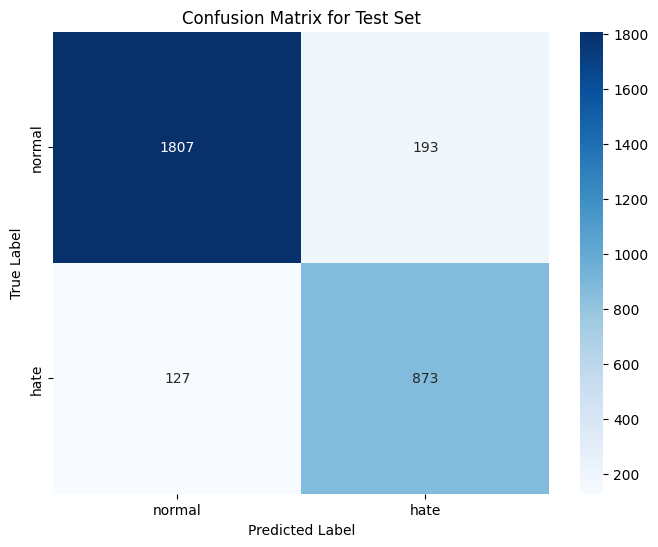


Confusion Matrix generated successfully.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'trainer', 'tokenized_datasets', and 'id2label' are available from previous steps

print("Generating predictions for the test set...")
# Use trainer.predict to get predictions for the entire test set
# This returns predictions (logits) and true labels
predictions_output = trainer.predict(tokenized_datasets["test"])

# Extract logits and true labels
test_logits = predictions_output.predictions
test_true_labels = predictions_output.label_ids

# Convert logits to predicted label IDs
test_predicted_labels = np.argmax(test_logits, axis=1)

print("Calculating Confusion Matrix...")
# Calculate the confusion matrix
cm = confusion_matrix(test_true_labels, test_predicted_labels)

# Define class names (from id2label mapping)
# Ensure the order matches your label IDs (0: normal, 1: hate)
class_names = [id2label[i] for i in sorted(id2label.keys())]

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,      # Annotate cells with the numeric values
    fmt="d",         # Format annotations as integers
    cmap="Blues",    # Color map
    cbar=True,       # Show color bar
    xticklabels=class_names, # Labels for predicted classes
    yticklabels=class_names  # Labels for true classes
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()

print("\nConfusion Matrix generated successfully.")

# **Visualize Training & Validation Progress**

Generating Training/Validation Loss and Metric Plots...


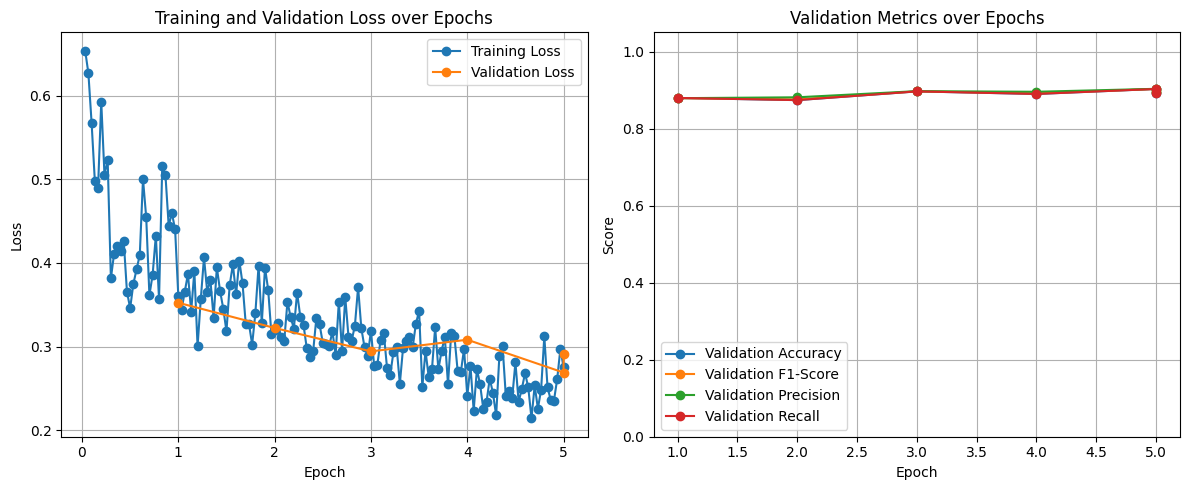


Training/Validation Loss and Metric Plots generated successfully.


In [13]:
import matplotlib.pyplot as plt
import pandas as pd # Using pandas for easier data handling

# Assuming 'trainer' object is available from previous steps
if 'trainer' not in locals():
    print("Error: 'trainer' object not found. Please re-run Step 5 (Revised) to initialize the trainer.")
else:
    print("Generating Training/Validation Loss and Metric Plots...")

    # Extract log history from the trainer
    log_history = trainer.state.log_history

    # Filter out relevant entries for plotting
    train_loss_epochs = []
    eval_metrics_epochs = []

    for entry in log_history:
        if 'loss' in entry and 'eval_loss' not in entry: # This is a training loss log
            # We want one training loss per epoch for simplicity in this plot.
            # Take the last reported training loss for the epoch.
            if not train_loss_epochs or train_loss_epochs[-1].get('epoch') != entry['epoch']:
                train_loss_epochs.append({'epoch': entry['epoch'], 'loss': entry['loss']})
            else: # Update if it's the same epoch, taking the last (most recent)
                train_loss_epochs[-1]['loss'] = entry['loss']
        elif 'eval_loss' in entry: # This is an evaluation log
            eval_metrics_epochs.append(entry)

    # Convert to DataFrames for easier plotting
    df_train_loss = pd.DataFrame(train_loss_epochs)
    df_eval_metrics = pd.DataFrame(eval_metrics_epochs)

    # --- Plotting Loss Curves ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    if not df_train_loss.empty:
        plt.plot(df_train_loss['epoch'], df_train_loss['loss'], label='Training Loss', marker='o')
    if not df_eval_metrics.empty:
        plt.plot(df_eval_metrics['epoch'], df_eval_metrics['eval_loss'], label='Validation Loss', marker='o')

    plt.title('Training and Validation Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()


    # --- Plotting Evaluation Metrics ---
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    if not df_eval_metrics.empty:
        plt.plot(df_eval_metrics['epoch'], df_eval_metrics['eval_accuracy'], label='Validation Accuracy', marker='o')
        plt.plot(df_eval_metrics['epoch'], df_eval_metrics['eval_f1'], label='Validation F1-Score', marker='o')
        plt.plot(df_eval_metrics['epoch'], df_eval_metrics['eval_precision'], label='Validation Precision', marker='o')
        plt.plot(df_eval_metrics['epoch'], df_eval_metrics['eval_recall'], label='Validation Recall', marker='o')

    plt.title('Validation Metrics over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 1.05) # Ensure y-axis from 0 to 1 for scores

    plt.tight_layout() # Adjust layout to prevent overlapping
    plt.show()

    print("\nTraining/Validation Loss and Metric Plots generated successfully.")